# **Inventory Optimization Dashboard** — Exploratory Data Analysis

This notebook explores inventory levels, demand, reorder risk, inventory
value, supplier performance and product-level patterns to identify
actionable insights for the Inventory Optimization Dashboard.

#### 1. Import Libraries

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

#### 2. Load Prepared Dataset

In [34]:
df = pd.read_csv("../Data/inventory_cleaned.csv")

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset shape:", df.shape)

Dataset shape: (91250, 19)


#### 3. Overall Inventory KPIs

In [35]:
total_inventory_value_observations = df["Inventory_Value"].sum()

average_inventory = df["Inventory_Level"].mean()

total_units_sold = df["Units_Sold"].sum()

average_daily_demand = df["Units_Sold"].mean()

reorder_risk_count = df["Reorder_Risk"].sum()

reorder_risk_percentage = (
    df["Reorder_Risk"].mean() * 100
)

print("Total Inventory Value:", round(total_inventory_value_observations, 2))
print("Average Inventory Level:", round(average_inventory, 2))
print("Total Units Sold:", total_units_sold)
print("Average Daily Demand:", round(average_daily_demand, 2))
print("Reorder Risk Records:", reorder_risk_count)
print("Reorder Risk %:", round(reorder_risk_percentage, 2))

Total Inventory Value: 525243991.12
Average Inventory Level: 471.52
Total Units Sold: 1829979
Average Daily Demand: 20.05
Reorder Risk Records: 5041
Reorder Risk %: 5.52


#### 4. SKU level Inventory Analysis

##### i. Inventory value by SKU

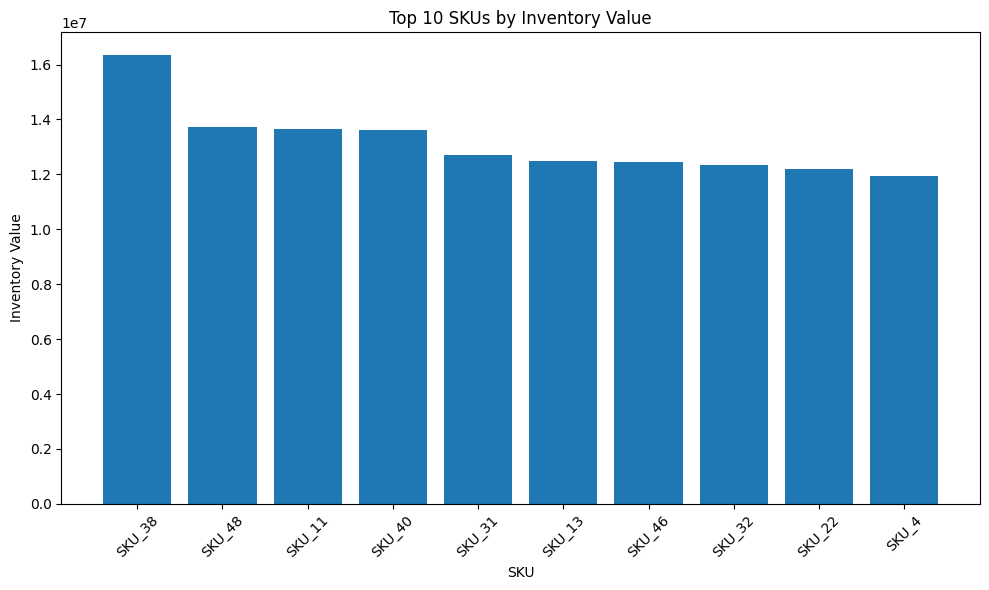

In [36]:
#1st modification
sku_inventory = (
    df.groupby("SKU_ID", observed=True)
      .agg(
          Inventory_Value=("Inventory_Value", "sum"),
          Average_Inventory=("Inventory_Level", "mean"),
          Units_Sold=("Units_Sold", "sum")
      )
      .sort_values("Inventory_Value", ascending=False)
)

sku_inventory.head(10)


top_10_skus = sku_inventory.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_skus.index.astype(str),
    top_10_skus["Inventory_Value"]
)

plt.title("Top 10 SKUs by Inventory Value")
plt.xlabel("SKU")
plt.ylabel("Inventory Value")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### ii. Inventory Level vs Demand

In [37]:
#2nd modification ot delete this
sku_demand_inventory = (
    df.groupby("SKU_ID", observed=True)
      .agg(
          Total_Units_Sold=("Units_Sold", "sum"),
          Average_Inventory=("Inventory_Level", "mean"),
          Total_Inventory_Value=("Inventory_Value", "sum")
      )
      .sort_values("Total_Units_Sold", ascending=False)
)

sku_demand_inventory.head(10)

,Total_Units_Sold,Average_Inventory,Total_Inventory_Value
SKU_ID,,,
SKU_18,37234,463.699726,10184572.45
SKU_1,37026,514.681644,11084810.67
SKU_33,37012,481.916164,10402775.24
SKU_13,36915,485.848219,12504434.27
SKU_47,36912,514.666849,9035680.22
SKU_9,36855,487.489863,9901916.08
SKU_4,36811,470.573151,11924966.98
SKU_12,36794,466.360548,10132231.82
SKU_3,36785,443.609315,9236415.25


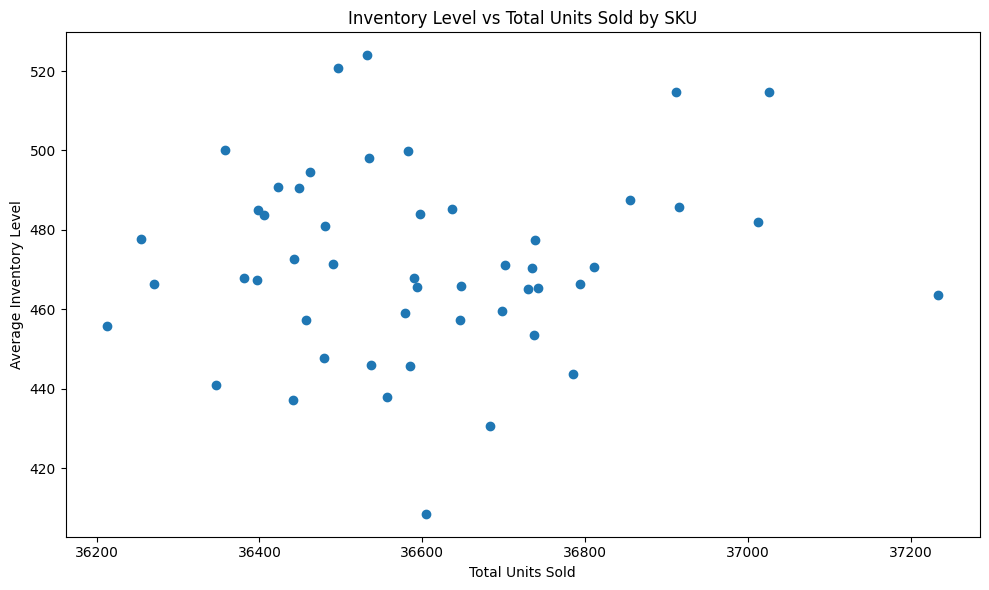

In [38]:
#creating scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    sku_demand_inventory["Total_Units_Sold"],
    sku_demand_inventory["Average_Inventory"]
)

plt.title("Inventory Level vs Total Units Sold by SKU")
plt.xlabel("Total Units Sold")
plt.ylabel("Average Inventory Level")

plt.tight_layout()
plt.show()

In [39]:
#calculate the correlation
correlation = (
    sku_demand_inventory["Total_Units_Sold"]
    .corr(sku_demand_inventory["Average_Inventory"])
)

print("Correlation between demand and average inventory:",
      round(correlation, 3))

Correlation between demand and average inventory: 0.083


#### 5. Reorder Risk Analysis

##### i. Reorder risk by SKU

In [40]:
sku_risk = (
    df.groupby("SKU_ID", observed=True)
      .agg(
          Reorder_Risk_Count=("Reorder_Risk", "sum"),
          Total_Records=("Reorder_Risk", "count"),
          Average_Inventory=("Inventory_Level", "mean"),
          Average_Reorder_Point=("Reorder_Point", "mean")
      )
)

sku_risk["Reorder_Risk_Percentage"] = (
    sku_risk["Reorder_Risk_Count"]
    / sku_risk["Total_Records"]
    * 100
)

sku_risk = sku_risk.sort_values(
    "Reorder_Risk_Percentage",
    ascending=False
)

sku_risk.head(10)

,Reorder_Risk_Count,Total_Records,Average_Inventory,Average_Reorder_Point,Reorder_Risk_Percentage
SKU_ID,,,,,
SKU_20,107,1825,470.461370,304.6,5.863014
SKU_14,107,1825,445.760548,283.6,5.863014
SKU_37,105,1825,465.055890,296.4,5.753425
SKU_22,104,1825,457.368767,290.8,5.698630
SKU_17,104,1825,490.636712,328.2,5.698630
SKU_18,104,1825,463.699726,294.6,5.698630
SKU_10,103,1825,459.178082,292.6,5.643836
SKU_39,103,1825,499.740274,331.8,5.643836
SKU_3,103,1825,443.609315,273.4,5.643836


##### ii. Reorder risk by Warehouse

In [41]:
#check warehouse level
warehouse_risk = (
    df.groupby("Warehouse_ID", observed=True)
      .agg(
          Reorder_Risk_Count=("Reorder_Risk", "sum"),
          Total_Records=("Reorder_Risk", "count")
      )
)

warehouse_risk["Reorder_Risk_Percentage"] = (
    warehouse_risk["Reorder_Risk_Count"]
    / warehouse_risk["Total_Records"]
    * 100
)

warehouse_risk.sort_values(
    "Reorder_Risk_Percentage",
    ascending=False
)

,Reorder_Risk_Count,Total_Records,Reorder_Risk_Percentage
Warehouse_ID,,,
WH_5,1019,18250,5.583562
WH_3,1012,18250,5.545205
WH_4,1008,18250,5.523288
WH_2,1004,18250,5.501370
WH_1,998,18250,5.468493


#### 6. Supplier & Lead-Time Analysis

In [42]:
supplier_analysis = (
    df.groupby("Supplier_ID", observed=True)
      .agg(
          Average_Lead_Time=("Supplier_Lead_Time_Days", "mean"),
          Average_Inventory=("Inventory_Level", "mean"),
          Inventory_Value=("Inventory_Value", "sum"),
          Reorder_Risk_Count=("Reorder_Risk", "sum"),
          Total_Records=("Reorder_Risk", "count")
    )
)

supplier_analysis["Reorder_Risk_Percentage"] = (
    supplier_analysis["Reorder_Risk_Count"]
    / supplier_analysis["Total_Records"]
    * 100
)

supplier_analysis.sort_values(
    "Average_Lead_Time",
    ascending=False
)

supplier_analysis.sort_values(
    "Reorder_Risk_Percentage",
    ascending=False
)

,Average_Lead_Time,Average_Inventory,Inventory_Value,Reorder_Risk_Count,Total_Records,Reorder_Risk_Percentage
Supplier_ID,,,,,,
SUP_6,7.900000,474.610685,44474872.45,408,7300,5.589041
SUP_3,8.260870,456.394640,45340026.03,468,8395,5.574747
SUP_8,8.500000,468.984638,67744535.09,569,10220,5.567515
SUP_2,8.423077,464.430242,50127302.52,527,9490,5.553214
SUP_4,8.640000,472.917699,57594320.83,505,9125,5.534247
SUP_9,8.187500,464.152911,29069391.27,323,5840,5.530822
SUP_10,7.407407,472.659158,58892568.37,545,9855,5.530188
SUP_7,7.558824,494.258743,71298113.68,681,12410,5.487510
SUP_1,8.107143,464.689922,56591560.29,560,10220,5.479452


In [43]:
#calculating whether lead time and reorder risk are related
lead_time_risk_correlation = (
    supplier_analysis["Average_Lead_Time"]
    .corr(supplier_analysis["Reorder_Risk_Percentage"])
)

print(
    "Correlation between supplier lead time and reorder risk:",
    round(lead_time_risk_correlation, 3)
)

Correlation between supplier lead time and reorder risk: 0.664


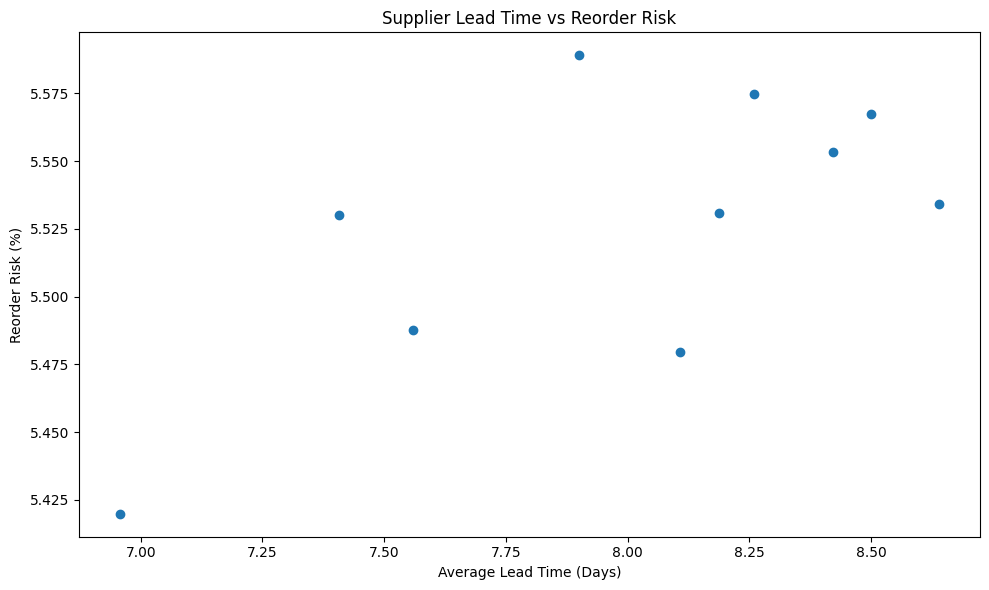

In [44]:
#creating scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    supplier_analysis["Average_Lead_Time"],
    supplier_analysis["Reorder_Risk_Percentage"]
)

plt.title("Supplier Lead Time vs Reorder Risk")
plt.xlabel("Average Lead Time (Days)")
plt.ylabel("Reorder Risk (%)")

plt.tight_layout()
plt.show()

#### 7. Inventory Efficiency Analysis

In [45]:
df["COGS"] = df["Units_Sold"] * df["Unit_Cost"]

In [46]:
#calculate SKU level matrics
sku_efficiency = (
    df.groupby("SKU_ID", observed=True)
      .agg(
          Total_Units_Sold=("Units_Sold", "sum"),
          Total_COGS=("COGS", "sum"),
          Average_Inventory_Value=("Inventory_Value", "mean"),
          Average_Inventory=("Inventory_Level", "mean")
      )
)

sku_efficiency["Inventory_Turnover"] = (
    sku_efficiency["Total_COGS"]
    / sku_efficiency["Average_Inventory_Value"]
)

sku_efficiency["Days_of_Inventory"] = (
    sku_efficiency["Average_Inventory"]
    / (sku_efficiency["Total_Units_Sold"] / 365)
)

sku_efficiency.sort_values(
    "Inventory_Turnover",
    ascending=False
).head(10)

,Total_Units_Sold,Total_COGS,Average_Inventory_Value,Average_Inventory,Inventory_Turnover,Days_of_Inventory
SKU_ID,,,,,,
SKU_50,36604,440173.78,4800.902471,408.510685,91.685633,4.073500
SKU_45,36347,416914.37,4902.159562,440.816438,85.047083,4.426720
SKU_44,36683,276995.36,3260.712537,430.552877,84.949334,4.284050
SKU_30,36557,401699.40,4750.678274,437.898630,84.556221,4.372159
SKU_14,36585,366394.49,4349.286532,445.760548,84.242435,4.447249
SKU_6,36213,437642.44,5268.903737,455.876712,83.061385,4.594897
SKU_35,36441,418078.83,5050.094066,437.272329,82.786345,4.379803
SKU_34,36537,287617.32,3480.785649,445.990137,82.630001,4.455385
SKU_3,36785,415009.70,5061.049452,443.609315,82.000720,4.401724


In [47]:
#lowest turnover products
sku_efficiency.sort_values(
    "Inventory_Turnover",
    ascending=True
).head(10)

,Total_Units_Sold,Total_COGS,Average_Inventory_Value,Average_Inventory,Inventory_Turnover,Days_of_Inventory
SKU_ID,,,,,,
SKU_16,36496,458535.11,6509.279671,520.842740,70.443295,5.208998
SKU_1,37026,428617.62,6073.868860,514.681644,70.567480,5.073700
SKU_47,36912,354425.25,4951.057655,514.666849,71.585765,5.089223
SKU_41,36532,348936.62,4847.197611,523.970411,71.987290,5.235114
SKU_26,36398,438327.52,6060.382011,485.128767,72.326715,4.864883
SKU_43,36535,443451.55,6035.912707,498.185205,73.468847,4.977080
SKU_17,36449,471393.79,6386.047748,490.636712,73.816202,4.913232
SKU_48,36597,555626.40,7515.024553,484.007123,73.935407,4.827243
SKU_11,36358,555711.23,7486.426510,500.064658,74.229171,5.020177


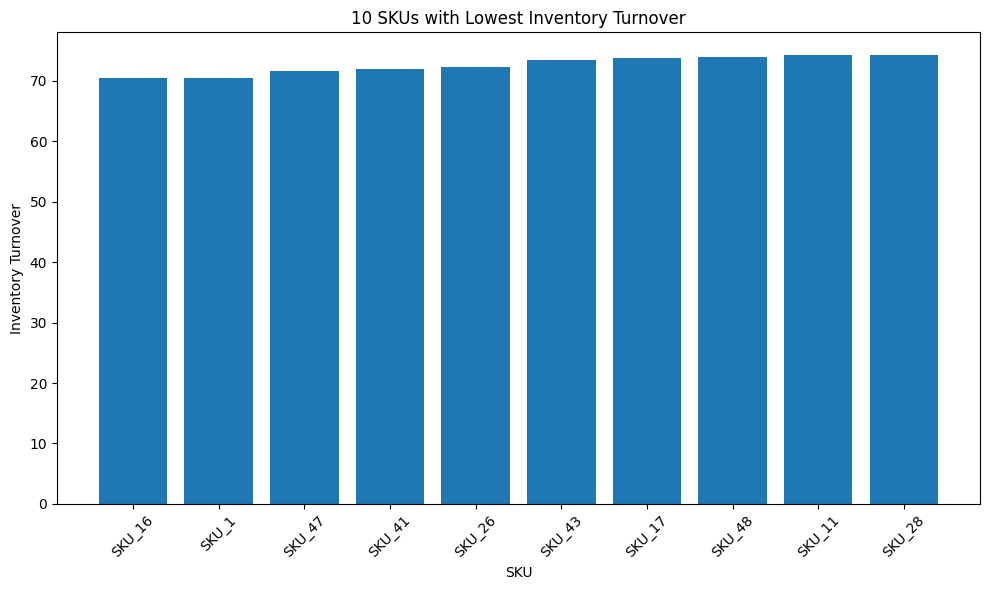

In [48]:
#visualizing 10 lowest turnover SKUs

slow_moving = (
    sku_efficiency
    .sort_values("Inventory_Turnover")
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.bar(
    slow_moving.index.astype(str),
    slow_moving["Inventory_Turnover"]
)

plt.title("10 SKUs with Lowest Inventory Turnover")
plt.xlabel("SKU")
plt.ylabel("Inventory Turnover")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [49]:
#finding lowest and highest turnover
print("\nLowest turnover SKU:")
print(
    sku_efficiency["Inventory_Turnover"]
    .idxmin(),
    round(sku_efficiency["Inventory_Turnover"].min(), 2)
)

print("\nHighest turnover SKU:")
print(
    sku_efficiency["Inventory_Turnover"]
    .idxmax(),
    round(sku_efficiency["Inventory_Turnover"].max(), 2)
)


Lowest turnover SKU:
SKU_16 70.44

Highest turnover SKU:
SKU_50 91.69


#### 8. Demand Forecast Accuracy

In [50]:
#calculating forecast error 

df["Forecast_Error"] = (
    df["Units_Sold"] - df["Demand_Forecast"]
)

df["Absolute_Forecast_Error"] = (
    df["Forecast_Error"].abs()
)

##### i. Calculating MAE and Forecast bias

In [51]:
#calculating overal metrics

mae = df["Absolute_Forecast_Error"].mean()

bias = df["Forecast_Error"].mean()

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Forecast Bias:", round(bias, 2))

Mean Absolute Error (MAE): 2.38
Forecast Bias: -0.03


In [52]:
#calculating error by SKU 

forecast_by_sku = (
    df.groupby("SKU_ID", observed=True)
      .agg(
          Actual_Demand=("Units_Sold", "sum"),
          Forecast_Demand=("Demand_Forecast", "sum"),
          MAE=("Absolute_Forecast_Error", "mean"),
          Forecast_Bias=("Forecast_Error", "mean")
      )
)

forecast_by_sku["Forecast_Error_%"] = (
    (
        forecast_by_sku["Forecast_Demand"]
        - forecast_by_sku["Actual_Demand"]
    )
    / forecast_by_sku["Actual_Demand"]
) * 100

forecast_by_sku.sort_values(
    "MAE",
    ascending=False
).head(10)

,Actual_Demand,Forecast_Demand,MAE,Forecast_Bias,Forecast_Error_%
SKU_ID,,,,,
SKU_23,36698,36717.30,2.450082,-0.010575,0.052591
SKU_44,36683,36649.41,2.446975,0.018405,-0.091568
SKU_47,36912,36880.77,2.444553,0.017112,-0.084607
SKU_24,36381,36571.72,2.442729,-0.104504,0.524230
SKU_29,36737,36651.31,2.425156,0.046953,-0.233253
SKU_17,36449,36415.65,2.423764,0.018274,-0.091498
SKU_36,36594,36394.07,2.422504,0.109551,-0.546346
SKU_28,36481,36483.19,2.419238,-0.001200,0.006003
SKU_22,36646,36769.94,2.415704,-0.067912,0.338209


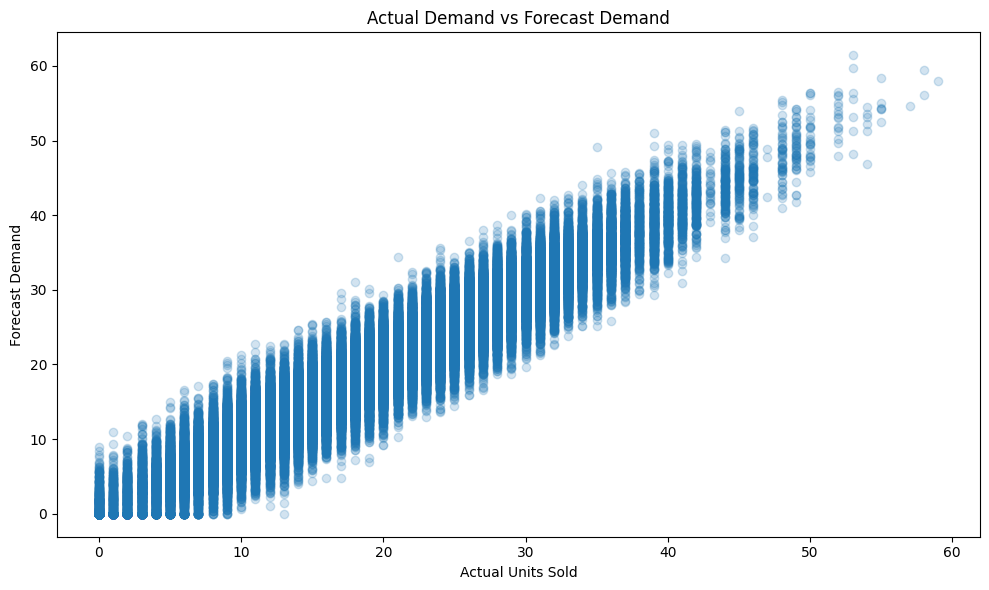

In [53]:
#visualising forecast accuracy

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Units_Sold"],
    df["Demand_Forecast"],
    alpha=0.2
)

plt.title("Actual Demand vs Forecast Demand")
plt.xlabel("Actual Units Sold")
plt.ylabel("Forecast Demand")

plt.tight_layout()
plt.show()

##### i. Forecast Accuracy Summary

In [54]:
total_absolute_error = df["Absolute_Forecast_Error"].sum()
total_actual_demand = df["Units_Sold"].sum()

wape = (
    total_absolute_error / total_actual_demand
) * 100

print("MAE:", round(mae, 2))
print("Forecast Bias:", round(bias, 2))
print("WAPE:", round(wape, 2), "%")

MAE: 2.38
Forecast Bias: -0.03
WAPE: 11.87 %


#### 9. Warehouse and Regional Analysis

##### i. Warehouse performance

In [55]:

warehouse_analysis = (
    df.groupby("Warehouse_ID", observed=True)
      .agg(
          Inventory_Value=("Inventory_Value", "sum"),
          Total_Units_Sold=("Units_Sold", "sum"),
          Average_Inventory=("Inventory_Level", "mean"),
          Reorder_Risk_Count=("Reorder_Risk", "sum")
      )
)

warehouse_analysis["Reorder_Risk_Percentage"] = (
    warehouse_analysis["Reorder_Risk_Count"]
    / df.groupby("Warehouse_ID", observed=True)["Reorder_Risk"].count()
    * 100
)

warehouse_analysis.sort_values(
    "Inventory_Value",
    ascending=False
)

,Inventory_Value,Total_Units_Sold,Average_Inventory,Reorder_Risk_Count,Reorder_Risk_Percentage
Warehouse_ID,,,,,
WH_2,1.213989e+08,366078,491.489644,1004,5.501370
WH_5,1.069279e+08,365114,467.116329,1019,5.583562
WH_4,1.011034e+08,365775,477.390301,1008,5.523288
WH_1,9.866216e+07,366902,466.056219,998,5.468493
WH_3,9.715166e+07,366110,455.559068,1012,5.545205


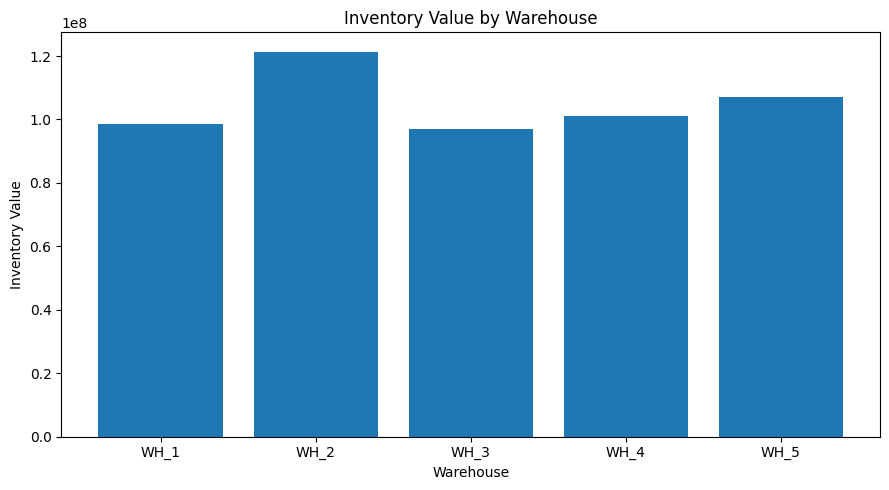

In [56]:
# visualising inventory value

plt.figure(figsize=(9, 5))

plt.bar(
    warehouse_analysis.index.astype(str),
    warehouse_analysis["Inventory_Value"]
)

plt.title("Inventory Value by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Inventory Value")

plt.tight_layout()
plt.show()

##### ii. Regional Analysis

In [57]:
region_analysis = (
    df.groupby("Region", observed=True)
      .agg(
          Inventory_Value=("Inventory_Value", "sum"),
          Total_Units_Sold=("Units_Sold", "sum"),
          Average_Inventory=("Inventory_Level", "mean"),
          Reorder_Risk_Count=("Reorder_Risk", "sum")
      )
)

region_analysis["Reorder_Risk_Percentage"] = (
    region_analysis["Reorder_Risk_Count"]
    / df.groupby("Region", observed=True)["Reorder_Risk"].count()
    * 100
)

region_analysis.sort_values(
    "Inventory_Value",
    ascending=False
)

,Inventory_Value,Total_Units_Sold,Average_Inventory,Reorder_Risk_Count,Reorder_Risk_Percentage
Region,,,,,
North,1.321490e+08,459849,470.785235,1322,5.754331
East,1.321224e+08,459961,473.046743,1220,5.319613
South,1.305695e+08,456954,472.159507,1213,5.338908
West,1.304031e+08,453215,470.085448,1286,5.684732


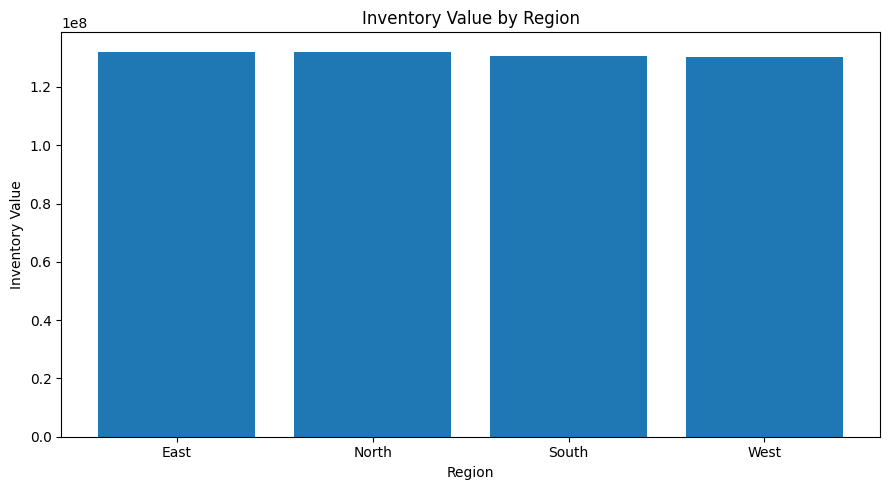

In [58]:
#visulisation

plt.figure(figsize=(9, 5))

plt.bar(
    region_analysis.index.astype(str),
    region_analysis["Inventory_Value"]
)

plt.title("Inventory Value by Region")
plt.xlabel("Region")
plt.ylabel("Inventory Value")

plt.tight_layout()
plt.show()

#### 10. Monthly Inventory and Demand trends

In [59]:
monthly_analysis = (
    df.groupby(df["Date"].dt.to_period("M"))
      .agg(
          Average_Inventory_Value=("Inventory_Value", "mean"),
          Total_Units_Sold=("Units_Sold", "sum"),
          Average_Inventory=("Inventory_Level", "mean"),
          Reorder_Risk_Count=("Reorder_Risk", "sum")
    )
)

monthly_analysis.index = monthly_analysis.index.astype(str)

monthly_analysis

,Average_Inventory_Value,Total_Units_Sold,Average_Inventory,Reorder_Risk_Count
Date,,,,
2024-01,6451.163573,176681,527.469935,325
2024-02,5605.457029,197188,459.948000,566
2024-03,5593.536001,231596,459.068387,646
2024-04,5548.001879,223793,454.417600,635
2024-05,5606.016366,210841,459.081161,604
2024-06,5614.603472,170013,460.489733,505
2024-07,5697.826375,134915,466.504129,390
2024-08,5820.668690,99019,477.487871,271
2024-09,5763.319508,76304,472.321067,225


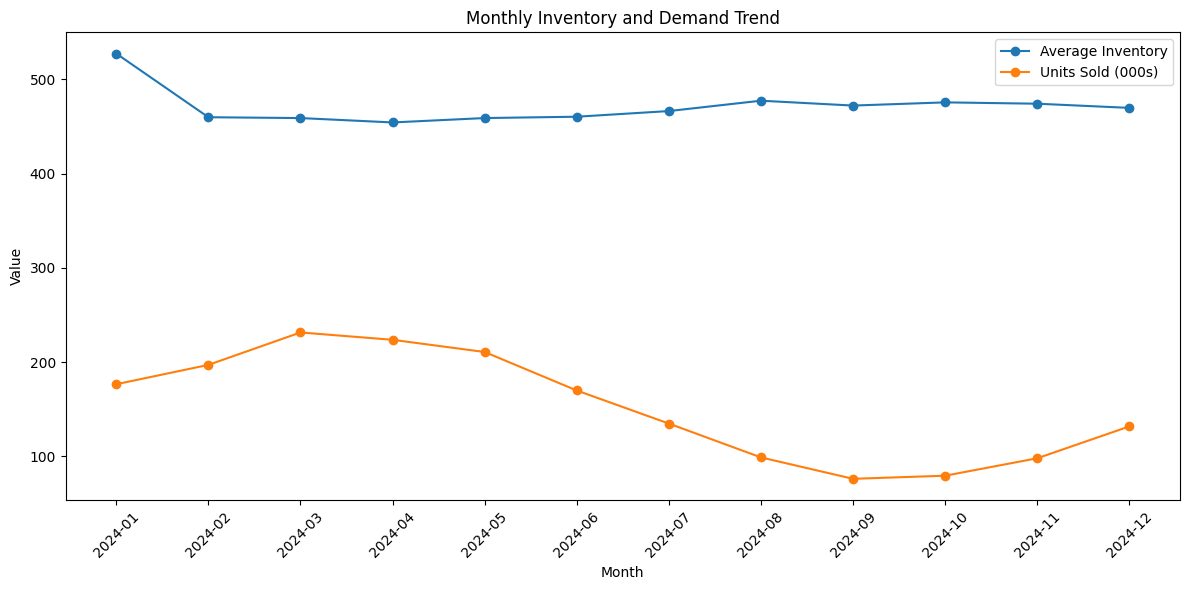

In [60]:
#creating trend chart

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_analysis.index,
    monthly_analysis["Average_Inventory"],
    marker="o",
    label="Average Inventory"
)

plt.plot(
    monthly_analysis.index,
    monthly_analysis["Total_Units_Sold"] / 1000,
    marker="o",
    label="Units Sold (000s)"
)

plt.title("Monthly Inventory and Demand Trend")
plt.xlabel("Month")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

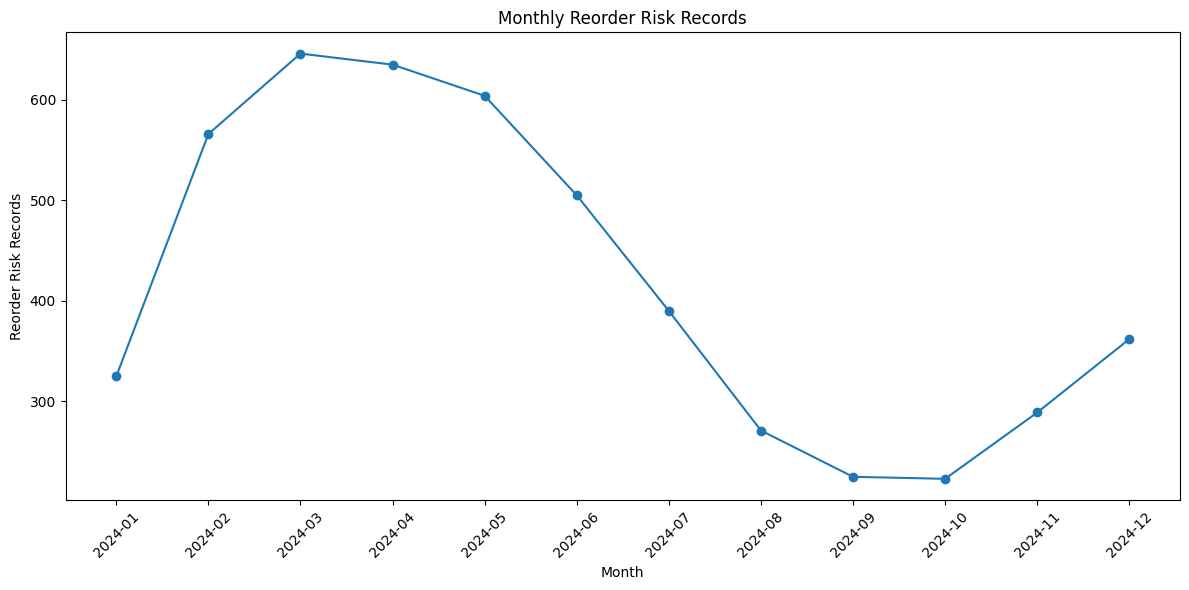

In [61]:
#creating reorder risk trend
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_analysis.index,
    monthly_analysis["Reorder_Risk_Count"],
    marker="o"
)

plt.title("Monthly Reorder Risk Records")
plt.xlabel("Month")
plt.ylabel("Reorder Risk Records")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 11. **Key Findings**

- Total recorded inventory value across all daily observations was approximately **$525.24M**.
- **5.52%** of records were classified as reorder-risk records based on inventory falling at or below the reorder point.
- Demand and average inventory showed a very weak positive relationship **(correlation = 0.083)**.
- Supplier lead time showed a positive association with reorder risk **(correlation = 0.664)** at the supplier level.
- Average inventory turnover was approximately **77.95x**, with an average inventory coverage of about **4.70 days**.
- Demand forecasts had a Mean Absolute Error (MAE) of **2.38 units** and a WAPE of **11.87%**.
- Warehouse-level reorder-risk percentages were relatively similar, while inventory value varied more noticeably across warehouses.
- Monthly demand and reorder-risk levels varied considerably throughout 2024, with reorder risk peaking in March and reaching its lowest level around September–October.